# Q5: 怎么知道策略有效？

Q4 我们给策略加上了规则——调仓频率、止损、止盈，学会了"不是所有合理的规则都有效"。现在手上有一个"看起来不错"的策略组合。

但"看起来不错"到底是什么意思？年化 15% 好不好？夏普 0.8 够不够？**跟什么比？**

更关键的问题：**这些数字是好几年平均出来的。如果某一年亏了 20%，你扛得住吗？**

### 路线图

**选什么标的（Q2 ✓）→ 每个买多少（Q3 ✓）→ 什么时候买卖（Q4 ✓）→ 怎么验证有效（Q5）→ 如何避免自欺欺人（Q6）**

本章解决第四步——给策略做一次"全面体检"。分四步：**跟什么比 → 每年都有收益吗 → 收益结构什么样 → 参数动一动崩不崩**

铁律不变：**先猜后验，数据说了算。**

### 被检查的策略

本章用 Q3-Q4 的四个策略作为"被检查对象"：

| 策略 | 来源 | 特点 |
|------|------|------|
| EqualWeight | Q3 等权 | 最简单，无参数 |
| RiskParity | Q3 风险平价 | 稳健，低敏感 |
| TopNRanking | Q3 动量排名 | 高收益但高波动 |
| RP + 止损 5% | Q4 最终产出 | 加了保护机制 |

### 前置条件

- 已完成 Q3、Q4
- 已安装 open-xquant：`pip install open-xquant[yfinance]`

### 操作方式

和前面一样：阅读说明 → 打开对应 spec → 复制到 TRAE → 观察结果 → 回来看解读。

---

## Step 1: 跟什么比？

Q4 的策略年化收益 15%、夏普 0.8——好不好？

直觉告诉我们：收益高就是好，夏普越大越好。但"好"是跟什么比？如果同期市场涨了 20%，你忙活半天不如躺平。

👉 **打开 `specs/spec-01-benchmark-and-metrics.md`，复制到 TRAE。**

数据范围: 2021-01-04 ~ 2026-03-06, 共 1250 个交易日
四个策略运行完毕

策略 vs 买入持有基准
策略                   累计收益     年化收益      波动率     最大回撤    夏普比      卡玛比     索提诺比
--------------------------------------------------------------------------------------------------------------
EqualWeight        84.37%   12.33%   12.49%  -16.86%   1.05     0.73     0.92
RiskParity         98.01%   13.77%   11.16%  -12.81%   1.29     1.08     1.16
TopNRanking       153.03%   18.71%   15.77%  -17.77%   1.27     1.05     1.11
RP+止损5%           106.23%   14.59%   10.61%  -13.07%   1.43     1.12     1.33
等权买入持有             94.82%   14.39%   13.00%  -17.24%   1.10        —        —

超额收益 / Alpha（策略累计 - 基准累计 94.82%）：
（还记得 Q0 说的吗？Beta 是跟着市场赚的钱，Alpha 是比市场多赚的钱——你的技能回报。）
  EqualWeight       -10.45%
  RiskParity         +3.18%
  TopNRanking       +58.20%
  RP+止损5%           +11.41%


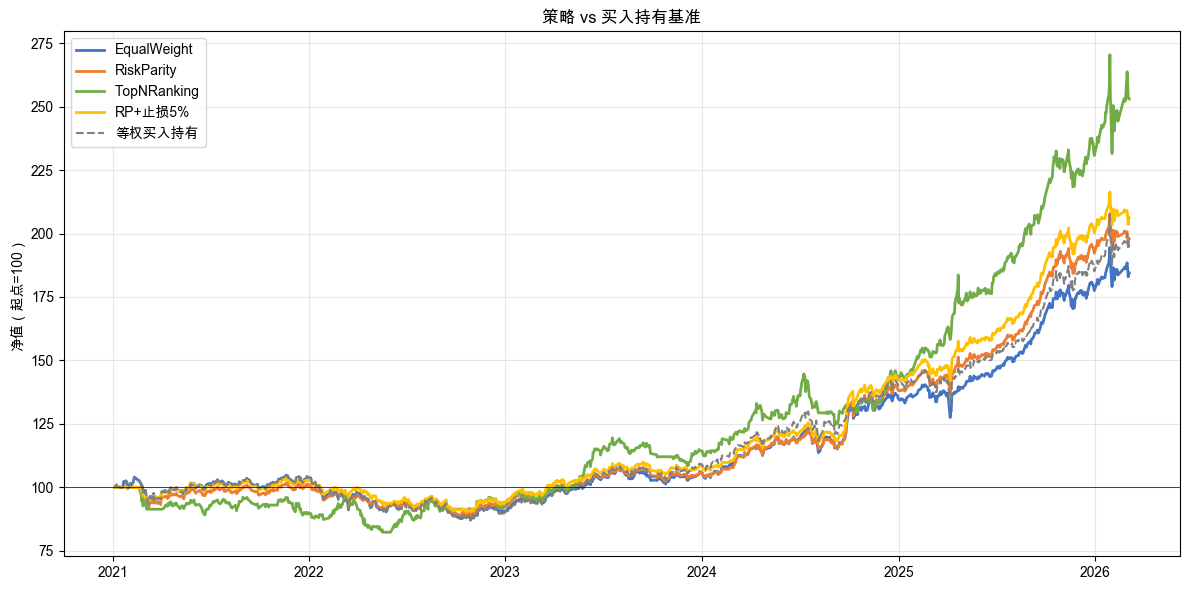


跑赢基准的策略：RiskParity、TopNRanking、RP+止损5%
没跑赢基准的策略：EqualWeight

三把尺子的冠军：
  夏普比最高: RP+止损5%（1.43）
  卡玛比最高: RP+止损5%（1.12）
  索提诺比最高: RP+止损5%（1.33）

年化收益好不好？取决于同期等权买入持有赚了多少。跑赢基准的部分，就是 Q0 说的 Alpha——你的技能回报。
夏普比、卡玛比、索提诺比是三把不同的尺子。夏普比看总波动，卡玛比看最大回撤，索提诺比只看下行波动。你最怕什么风险，就用什么尺子。

整体指标看着还行——但这是好几年平均出来的。每一年都赚钱吗？


In [43]:
from oxq.core import Engine, Strategy
from oxq.data import YFinanceDownloader, LocalMarketDataProvider
from oxq.indicators import RollingVolatility, Momentum, Ratio
from oxq.signals import EqualWeight, RiskParity, TopNRanking
from oxq.rules import RebalanceRule, StopLossRule
from oxq.trade import SimBroker, PercentageFee
from oxq.universe import StaticUniverse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# ── 常量 ──
SYMBOLS = ("510300.SS", "513100.SS", "518880.SS")
SYMBOL_NAMES = {
    "510300.SS": "沪深300ETF",
    "513100.SS": "纳指100ETF",
    "518880.SS": "黄金ETF",
}
START = "2021-01-01"
today = pd.Timestamp.now().strftime("%Y-%m-%d")
FEE_MODEL = PercentageFee(rate=Decimal("0.001"), min_fee=Decimal("5"))

# ── 下载数据 ──
downloader = YFinanceDownloader()
for sym in SYMBOLS:
    downloader.download(sym, start=START, end=today)

universe = StaticUniverse(symbols=SYMBOLS, name="global-macro-etf")
market = LocalMarketDataProvider()

# ── 共同交易日 ──
prices = {}
for sym in SYMBOLS:
    prices[sym] = market.get_bars(sym, START, today)["close"]

common_days = prices[SYMBOLS[0]].index
for sym in SYMBOLS[1:]:
    common_days = common_days.intersection(prices[sym].index)

print(f"数据范围: {common_days[0].date()} ~ {common_days[-1].date()}, 共 {len(common_days)} 个交易日")

# ── 辅助函数 ──
def run_strategy(signal_cfg, indicators_cfg, freq=10, stop_loss=None):
    """运行回测，返回 RunResult。含交易成本。"""
    order_rules = [StopLossRule(threshold=stop_loss)] if stop_loss else []
    strategy = Strategy(
        name="test",
        universe=universe,
        indicators=indicators_cfg,
        signals={"tw": signal_cfg},
        rebalance_rules=[RebalanceRule(weight_col="tw", frequency=freq)],
        order_rules=order_rules,
        entry_rules=[],
        exit_rules=[],
    )
    broker = SimBroker(fee_model=FEE_MODEL)
    return Engine().run(
        strategy,
        market=LocalMarketDataProvider(),
        broker=broker,
        start=START,
        end=today,
    )

# ── 策略配置 ──
RP_IND = {"vol": (RollingVolatility(), {"column": "close", "period": 20})}
RP_SIG = (RiskParity(), {"vol": "vol"})

EW_IND = {}
EW_SIG = (EqualWeight(), {})

TNR_IND = {
    "vol": (RollingVolatility(), {"column": "close", "period": 20}),
    "mom": (Momentum(), {"column": "close", "period": 20}),
    "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
}
TNR_SIG = (TopNRanking(), {"score": "ram", "n": 3, "filter_negative": True})

# ── 运行四个策略 ──
results = {}
results["EqualWeight"] = run_strategy(EW_SIG, EW_IND, freq=10)
results["RiskParity"] = run_strategy(RP_SIG, RP_IND, freq=10)
results["TopNRanking"] = run_strategy(TNR_SIG, TNR_IND, freq=10)
results["RP+止损5%"] = run_strategy(RP_SIG, RP_IND, freq=10, stop_loss=0.05)

print("四个策略运行完毕")

# ══════════════════════════════════════════════
# 买入持有基准
# ══════════════════════════════════════════════
eq_bh_prices = pd.DataFrame({sym: prices[sym].reindex(common_days) for sym in SYMBOLS}).dropna()
eq_bh_norm = eq_bh_prices.div(eq_bh_prices.iloc[0])
eq_bh_portfolio = eq_bh_norm.mean(axis=1)
bh_total_return = eq_bh_portfolio.iloc[-1] - 1

n_years = len(common_days) / 252
bh_ann_return = (1 + bh_total_return) ** (1 / n_years) - 1
eq_bh_daily_ret = eq_bh_portfolio.pct_change().dropna()
bh_vol = eq_bh_daily_ret.std() * np.sqrt(252)
eq_bh_cummax = eq_bh_portfolio.cummax()
bh_max_dd = ((eq_bh_portfolio - eq_bh_cummax) / eq_bh_cummax).min()
bh_sharpe = (eq_bh_daily_ret.mean() * 252) / (eq_bh_daily_ret.std() * np.sqrt(252)) if eq_bh_daily_ret.std() > 0 else 0

# ══════════════════════════════════════════════
# 对比表
# ══════════════════════════════════════════════
print("\n策略 vs 买入持有基准")
print("=" * 110)
print(f"{'策略':<16} {'累计收益':>8} {'年化收益':>8} {'波动率':>8} {'最大回撤':>8} {'夏普比':>6} {'卡玛比':>8} {'索提诺比':>8}")
print("-" * 110)

for name, r in results.items():
    print(f"{name:<16} {r.total_return():>8.2%} {r.annualized_return():>8.2%} "
          f"{r.annualized_volatility():>8.2%} {r.max_drawdown():>8.2%} "
          f"{r.sharpe_ratio():>6.2f} {r.calmar_ratio():>8.2f} {r.sortino_ratio():>8.2f}")

# 基准行
print(f"{'等权买入持有':<16} {bh_total_return:>8.2%} {bh_ann_return:>8.2%} "
      f"{bh_vol:>8.2%} {bh_max_dd:>8.2%} "
      f"{bh_sharpe:>6.2f} {'—':>8} {'—':>8}")

# 超额收益 = Alpha
print(f"\n超额收益 / Alpha（策略累计 - 基准累计 {bh_total_return:.2%}）：")
print(f"（还记得 Q0 说的吗？Beta 是跟着市场赚的钱，Alpha 是比市场多赚的钱——你的技能回报。）")
for name, r in results.items():
    excess = r.total_return() - bh_total_return
    print(f"  {name:<16} {excess:>+8.2%}")

# ══════════════════════════════════════════════
# 净值曲线对比图
# ══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'EqualWeight': '#4472C4', 'RiskParity': '#ED7D31',
          'TopNRanking': '#70AD47', 'RP+止损5%': '#FFC000'}

for name, r in results.items():
    equity = pd.Series(dict(r.equity_curve))
    equity.index = pd.to_datetime(equity.index)
    equity = equity.reindex(common_days).dropna()
    norm = equity / equity.iloc[0] * 100
    ax.plot(norm.index, norm.values, label=name, color=colors[name], linewidth=2)

# 基准（灰色虚线）
bh_norm = eq_bh_portfolio / eq_bh_portfolio.iloc[0] * 100
ax.plot(bh_norm.index, bh_norm.values, label='等权买入持有', linestyle='--', color='gray', linewidth=1.5)

ax.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('策略 vs 买入持有基准')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 分析 ──
beat_bh = [name for name, r in results.items() if r.total_return() > bh_total_return]
miss_bh = [name for name, r in results.items() if r.total_return() <= bh_total_return]

if beat_bh:
    print(f"\n跑赢基准的策略：{'、'.join(beat_bh)}")
if miss_bh:
    print(f"没跑赢基准的策略：{'、'.join(miss_bh)}")

# 不同指标排名
names = list(results.keys())
sharpe_best = max(names, key=lambda n: results[n].sharpe_ratio())
calmar_best = max(names, key=lambda n: results[n].calmar_ratio())
sortino_best = max(names, key=lambda n: results[n].sortino_ratio())

print(f"\n三把尺子的冠军：")
print(f"  夏普比最高: {sharpe_best}（{results[sharpe_best].sharpe_ratio():.2f}）")
print(f"  卡玛比最高: {calmar_best}（{results[calmar_best].calmar_ratio():.2f}）")
print(f"  索提诺比最高: {sortino_best}（{results[sortino_best].sortino_ratio():.2f}）")

if len({sharpe_best, calmar_best, sortino_best}) > 1:
    print("  → 不同的尺子给出了不同的冠军！")

print(f"\n年化收益好不好？取决于同期等权买入持有赚了多少。跑赢基准的部分，就是 Q0 说的 Alpha——你的技能回报。")
print(f"夏普比、卡玛比、索提诺比是三把不同的尺子。夏普比看总波动，卡玛比看最大回撤，索提诺比只看下行波动。你最怕什么风险，就用什么尺子。")
print(f"\n整体指标看着还行——但这是好几年平均出来的。每一年都赚钱吗？")

### Step 1 解读

第一个认知升级：**"好不好"必须有参照物。**

年化 15% 听起来很棒，但如果同期"什么都不做"（等权买入持有三只 ETF）就能赚 12%，那你忙活半天只多赚了 3%。多出来的这部分叫**超额收益**——还记得 Q0 说的 Alpha 吗？**Alpha 就是超额收益，是你比市场多赚的部分，是你的技能回报。** 如果超额收益为零甚至为负，说明你的策略没有创造 Alpha——还不如买指数基金躺平。

第二个认知升级：**不同的尺子量出不同的结论。**

- **夏普比**：每承受 1% 的总波动，能换来多少收益。上涨和下跌的波动都算"风险"
- **卡玛比**：年化收益 / 最大回撤。如果你最怕"一次跌太深"，卡玛比是最直接的尺子
- **索提诺比**：只用下行波动率做分母。上涨波动不是风险——涨得猛不应该被惩罚

三把尺子可能给出不同的冠军。这不矛盾——它们关注的风险维度不同。你最怕什么，就用什么尺子。

但这些都是好几年平均出来的数字。**平均年化 10% 听着不错——但如果其中一年亏了 20%，你扛得住吗？**

---

## Step 2: 每年都有收益吗？

整体指标是多年的平均值——可能掩盖某些年份的亏损。就像考试平均 80 分，但其中一科考了 30 分。

直觉告诉我们：平均好就是好吧，哪年赚哪年亏不重要？

真的吗？拆开看看。

👉 **打开 `specs/spec-02-annual-breakdown.md`，复制到 TRAE。**

逐年收益对比
年份        EqualWeight   RiskParity  TopNRanking      RP+止损5%           基准
--------------------------------------------------------------------------------
2021          3.76%        1.03%      -10.09% *      3.04%        4.09%  
2022        -12.72% *     -8.55% *      3.04%       -8.63% *    -13.44% *
2023         17.04%       15.03%       23.48%       15.67%       21.21%  
2024         27.55%       30.12%       24.50%       30.65%       28.31%  
2025         31.29%       39.01%       62.02%       40.74%       32.10%  
2026          3.88%        3.00%        9.65%        3.00%        5.24%  

（* 标注负收益年份）


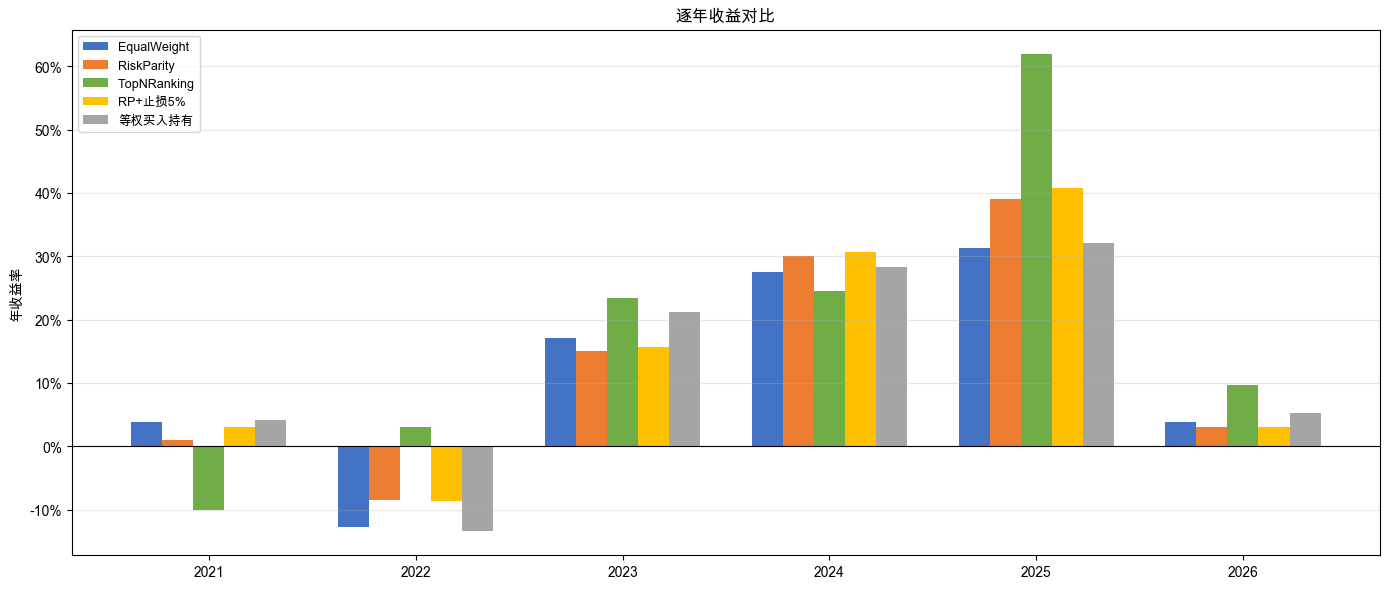


TopNRanking 负收益年份深挖：[2021]
不同动量窗口在负收益年份的表现：

窗口               2021
---------------------
period=5        -9.48%
period=10       -7.97%
period=15       -5.08%
period=20      -10.09%
period=25      -11.09%
period=30       -9.14%

所有动量窗口在负收益年份都亏钱！
这不是参数选错了——是动量策略的结构性弱点。
当市场反复上下波动、没有明确方向时，动量指标有滞后性：过去涨得好 ≠ 未来继续涨。

EqualWeight: [2022] 年份为负收益

RiskParity: [2022] 年份为负收益

TopNRanking: [2021] 年份为负收益

RP+止损5%: [2022] 年份为负收益

整体指标可以掩盖很多问题，逐年拆开才能看到真实的持有体验。
知道了每年的表现——但每个月呢？赚钱是稳定地赚，还是靠几次大赚？


In [44]:
# ══════════════════════════════════════════════
# Step 2: 逐年收益拆解
# ══════════════════════════════════════════════

# ── 按年拆解四个策略 ──
annual_data = {}
for name, r in results.items():
    daily_ret = r.daily_returns()
    if daily_ret.empty:
        continue
    daily_ret.index = pd.to_datetime(daily_ret.index)

    eq = pd.Series(dict(r.equity_curve))
    eq.index = pd.to_datetime(eq.index)

    years = sorted(daily_ret.index.year.unique())
    year_stats = {}
    for year in years:
        yr_ret = daily_ret[daily_ret.index.year == year]
        if len(yr_ret) < 10:
            continue
        annual_ret = (1 + yr_ret).prod() - 1
        annual_vol = yr_ret.std() * np.sqrt(252)
        annual_sharpe = (yr_ret.mean() * 252) / (yr_ret.std() * np.sqrt(252)) if yr_ret.std() > 0 else 0

        yr_eq = eq[eq.index.year == year]
        yr_dd = 0
        if len(yr_eq) > 1:
            yr_cummax = yr_eq.cummax()
            yr_dd = ((yr_eq - yr_cummax) / yr_cummax).min()

        year_stats[year] = {
            "return": annual_ret,
            "vol": annual_vol,
            "sharpe": annual_sharpe,
            "max_dd": yr_dd,
        }
    annual_data[name] = year_stats

# ── 基准逐年收益 ──
eq_bh_daily = eq_bh_portfolio.pct_change().dropna()
bh_annual = {}
for year in sorted(eq_bh_daily.index.year.unique()):
    yr_ret = eq_bh_daily[eq_bh_daily.index.year == year]
    if len(yr_ret) < 10:
        continue
    bh_annual[year] = (1 + yr_ret).prod() - 1

# ── 打印逐年对比表 ──
all_years = sorted(set().union(*[d.keys() for d in annual_data.values()]))
strat_names = list(results.keys())

print("逐年收益对比")
print("=" * 80)
header = f"{'年份':<8}"
for name in strat_names:
    short = name[:12]
    header += f" {short:>12}"
header += f" {'基准':>12}"
print(header)
print("-" * 80)

for year in all_years:
    row = f"{year:<8}"
    for name in strat_names:
        if year in annual_data[name]:
            ret = annual_data[name][year]["return"]
            mark = " *" if ret < 0 else "  "
            row += f" {ret:>10.2%}{mark}"
        else:
            row += f" {'—':>12}"
    bh_ret = bh_annual.get(year, None)
    if bh_ret is not None:
        mark = " *" if bh_ret < 0 else "  "
        row += f" {bh_ret:>10.2%}{mark}"
    else:
        row += f" {'—':>12}"
    print(row)

print("\n（* 标注负收益年份）")

# ── 逐年收益柱状图 ──
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(all_years))
width = 0.15
bar_colors = ['#4472C4', '#ED7D31', '#70AD47', '#FFC000', '#A5A5A5']

for i, name in enumerate(strat_names):
    vals = [annual_data[name].get(y, {}).get("return", 0) for y in all_years]
    ax.bar(x + i * width, vals, width, label=name, color=bar_colors[i])

# 基准
bh_vals = [bh_annual.get(y, 0) for y in all_years]
ax.bar(x + len(strat_names) * width, bh_vals, width, label='等权买入持有', color=bar_colors[4])

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x + width * len(strat_names) / 2)
ax.set_xticklabels(all_years)
ax.set_ylabel('年收益率')
ax.set_title('逐年收益对比')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════
# 深挖 TopNRanking 负收益年份
# ══════════════════════════════════════════════

# 找 TopNRanking 的负收益年份
tnr_neg_years = [y for y, s in annual_data["TopNRanking"].items() if s["return"] < 0]

if tnr_neg_years:
    print(f"\nTopNRanking 负收益年份深挖：{tnr_neg_years}")
    print("=" * 60)
    print(f"不同动量窗口在负收益年份的表现：")

    mom_periods = [5, 10, 15, 20, 25, 30]
    print(f"\n{'窗口':<10}", end="")
    for y in tnr_neg_years:
        print(f" {y:>10}", end="")
    print()
    print("-" * (10 + 11 * len(tnr_neg_years)))

    for p in mom_periods:
        ind = {
            "vol": (RollingVolatility(), {"column": "close", "period": 20}),
            "mom": (Momentum(), {"column": "close", "period": p}),
            "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
        }
        sig = (TopNRanking(), {"score": "ram", "n": 3, "filter_negative": True})
        r = run_strategy(sig, ind, freq=10)

        daily_ret = r.daily_returns()
        daily_ret.index = pd.to_datetime(daily_ret.index)

        print(f"period={p:<4}", end="")
        for y in tnr_neg_years:
            yr_ret = daily_ret[daily_ret.index.year == y]
            if len(yr_ret) > 0:
                ret = (1 + yr_ret).prod() - 1
                print(f" {ret:>10.2%}", end="")
            else:
                print(f" {'—':>10}", end="")
        print()

    all_neg = True
    for p in mom_periods:
        ind = {
            "vol": (RollingVolatility(), {"column": "close", "period": 20}),
            "mom": (Momentum(), {"column": "close", "period": p}),
            "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
        }
        sig = (TopNRanking(), {"score": "ram", "n": 3, "filter_negative": True})
        r = run_strategy(sig, ind, freq=10)
        daily_ret = r.daily_returns()
        daily_ret.index = pd.to_datetime(daily_ret.index)
        for y in tnr_neg_years:
            yr_ret = daily_ret[daily_ret.index.year == y]
            if len(yr_ret) > 0 and (1 + yr_ret).prod() - 1 > 0:
                all_neg = False

    if all_neg:
        print(f"\n所有动量窗口在负收益年份都亏钱！")
        print(f"这不是参数选错了——是动量策略的结构性弱点。")
        print(f"当市场反复上下波动、没有明确方向时，动量指标有滞后性：过去涨得好 ≠ 未来继续涨。")
    else:
        print(f"\n部分窗口能避开亏损——参数选择确实有影响。")
else:
    print(f"\nTopNRanking 每年都是正收益，无需深挖。")

# ── 分析 ──
for name in strat_names:
    neg_years = [y for y, s in annual_data[name].items() if s["return"] < 0]
    if neg_years:
        print(f"\n{name}: {neg_years} 年份为负收益")
    else:
        print(f"\n{name}: 每年都是正收益")

print(f"\n整体指标可以掩盖很多问题，逐年拆开才能看到真实的持有体验。")
print(f"知道了每年的表现——但每个月呢？赚钱是稳定地赚，还是靠几次大赚？")

### Step 2 解读

整体指标是"平均分"——逐年拆开才是"每科成绩单"。

**分段检验**揭示了两个重要发现：

1. **没有哪个策略"年年赚钱"。** 某些年份策略和基准一起亏，说明策略并没有真正提供"下跌保护"。这是资产配置策略的特点——它能分散风险，但不能消除市场整体下跌带来的损失。

2. **TopNRanking 的负收益不是参数问题。** 换遍所有动量窗口（5 天到 30 天），在市场反复上下波动的年份全部亏钱。这是**动量策略的结构性弱点**——动量指标基于"过去涨得好"来买入，但当市场来回波动、没有明确方向时，过去涨得好的恰恰可能是"已经涨到头了"的那个。动量指标有天然的**滞后性**。

**数据说了算：逐年拆开，才能看到整体指标掩盖的问题。不同策略类型有不同的市场环境偏好。**

但年度还是太粗了——知道了哪年亏钱，但赚钱的年份里，是每月稳稳地赚，还是靠某几个月的暴利覆盖其他月份的亏损？

---

## Step 3: 收益结构什么样？

年度表现解释了"什么时候赚、什么时候亏"，但没解释"怎么赚的"——是每个月稳稳地赚一点，还是靠几次大赚覆盖很多次小亏？

同样赚钱的两个策略，赚法可能完全不同。你能接受"一年中 8 个月亏钱、靠 4 个月大赚拉回来"的策略吗？

另外，回撤不只是一个数字——最大回撤 -15% 但 3 个月恢复，和最大回撤 -10% 但 1 年没恢复，哪个更痛苦？

👉 **打开 `specs/spec-03-return-distribution-and-drawdown.md`，复制到 TRAE。**

月度收益统计对比
策略                   胜率      平均盈利月      平均亏损月      盈亏比     盈亏因子      最好月      最差月     连赢     连亏
--------------------------------------------------------------------------------------------------------------
EqualWeight       63.5%      2.54%     -1.63%     1.55     2.70    9.52%   -7.82%      8      3
RiskParity        61.9%      2.79%     -1.56%     1.79     2.91   11.29%   -6.09%     11      4
TopNRanking       61.9%      3.88%     -2.21%     1.75     2.85    9.88%   -8.36%     11      4
RP+止损5%           63.5%      2.77%     -1.55%     1.79     3.12   11.74%   -5.52%     11      4


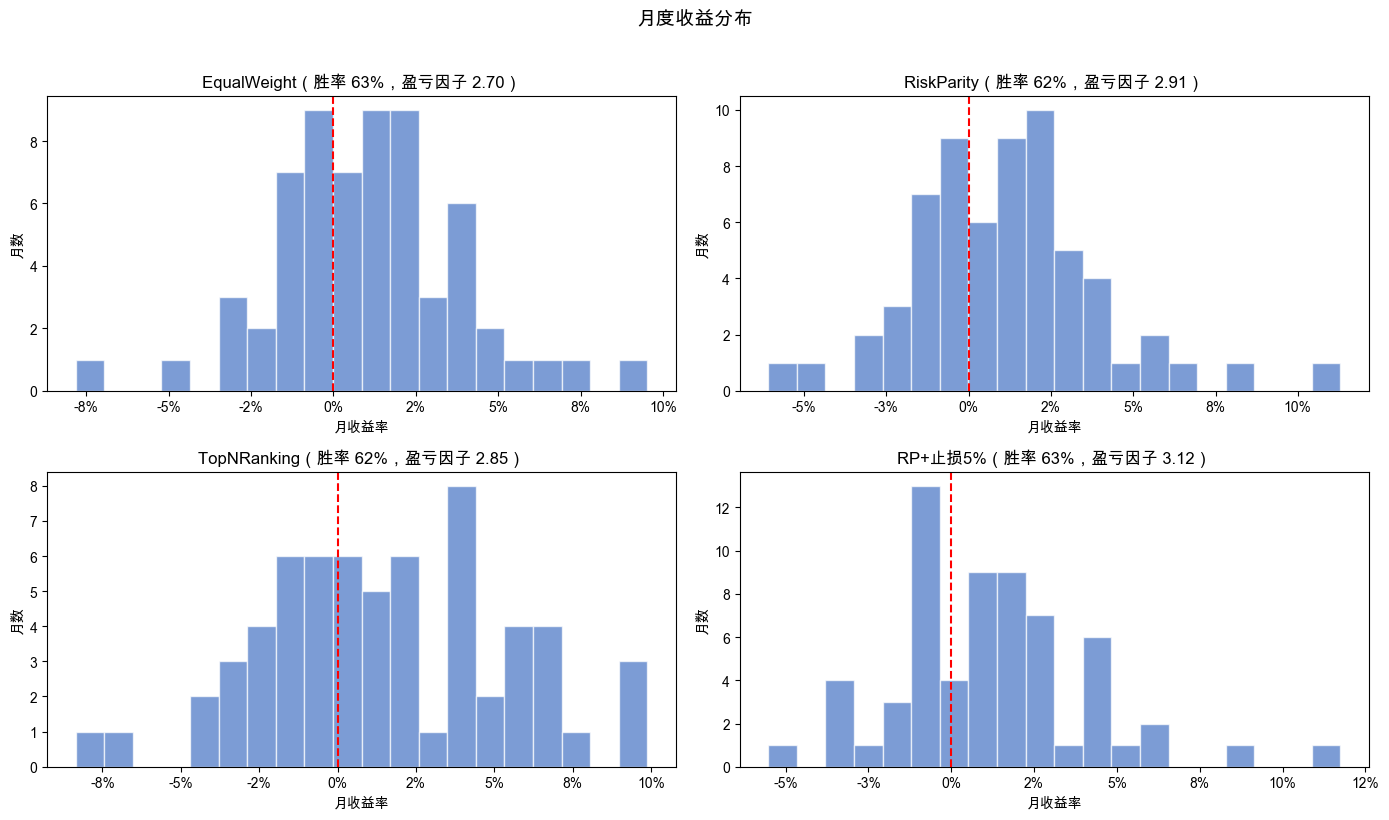


各策略赚法对比：
  EqualWeight      胜率 63%，赚的月份平均赚 2.54%，亏的月份平均亏 1.63%，盈亏比 1.55
  RiskParity       胜率 62%，赚的月份平均赚 2.79%，亏的月份平均亏 1.56%，盈亏比 1.79
  TopNRanking      胜率 62%，赚的月份平均赚 3.88%，亏的月份平均亏 2.21%，盈亏比 1.75
  RP+止损5%          胜率 63%，赚的月份平均赚 2.77%，亏的月份平均亏 1.55%，盈亏比 1.79

盈亏因子（总盈利 / 总亏损）是最直接的'赚钱效率'指标：大于 1 说明赚的比亏的多，大于 2 算优秀。


In [45]:
# ══════════════════════════════════════════════
# Step 3: 收益结构——月度分布 + 回撤深度
# ══════════════════════════════════════════════

# ── 月度收益分布分析 ──
strat_names = list(results.keys())
monthly_stats = {}

for name in strat_names:
    r = results[name]
    monthly = r.monthly_returns()
    if monthly.empty:
        continue

    n_months = len(monthly)
    n_positive = (monthly > 0).sum()
    n_negative = (monthly <= 0).sum()
    win_rate = n_positive / n_months

    avg_win = monthly[monthly > 0].mean() if n_positive > 0 else 0
    avg_loss = abs(monthly[monthly <= 0].mean()) if n_negative > 0 else 0
    win_loss_ratio = avg_win / avg_loss if avg_loss > 0 else float("inf")

    total_gain = monthly[monthly > 0].sum()
    total_loss = abs(monthly[monthly <= 0].sum())
    profit_factor = total_gain / total_loss if total_loss > 0 else float("inf")

    # 连续盈亏
    streaks = []
    current_streak = 0
    for ret in monthly:
        if ret > 0:
            current_streak = current_streak + 1 if current_streak > 0 else 1
        else:
            current_streak = current_streak - 1 if current_streak < 0 else -1
        streaks.append(current_streak)

    max_win_streak = max(streaks) if streaks else 0
    max_loss_streak = abs(min(streaks)) if streaks else 0

    monthly_stats[name] = {
        "monthly": monthly,
        "win_rate": win_rate,
        "avg_win": avg_win,
        "avg_loss": avg_loss,
        "win_loss_ratio": win_loss_ratio,
        "profit_factor": profit_factor,
        "median": monthly.median(),
        "best": monthly.max(),
        "worst": monthly.min(),
        "max_win_streak": max_win_streak,
        "max_loss_streak": max_loss_streak,
    }

# ── 打印月度统计对比表 ──
print("月度收益统计对比")
print("=" * 110)
print(f"{'策略':<16} {'胜率':>6} {'平均盈利月':>10} {'平均亏损月':>10} {'盈亏比':>8} {'盈亏因子':>8} {'最好月':>8} {'最差月':>8} {'连赢':>6} {'连亏':>6}")
print("-" * 110)

for name in strat_names:
    s = monthly_stats[name]
    print(f"{name:<16} {s['win_rate']:>6.1%} {s['avg_win']:>10.2%} {-s['avg_loss']:>10.2%} "
          f"{s['win_loss_ratio']:>8.2f} {s['profit_factor']:>8.2f} "
          f"{s['best']:>8.2%} {s['worst']:>8.2%} "
          f"{s['max_win_streak']:>6} {s['max_loss_streak']:>6}")

# ── 月度收益分布直方图 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, name in enumerate(strat_names):
    ax = axes[i]
    monthly = monthly_stats[name]["monthly"]
    win_rate = monthly_stats[name]["win_rate"]
    pf = monthly_stats[name]["profit_factor"]

    ax.hist(monthly, bins=20, color='#4472C4', alpha=0.7, edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name}（胜率 {win_rate:.0%}，盈亏因子 {pf:.2f}）')
    ax.set_xlabel('月收益率')
    ax.set_ylabel('月数')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('月度收益分布', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 分析：各策略赚法对比 ──
print(f"\n各策略赚法对比：")
for name in strat_names:
    s = monthly_stats[name]
    print(f"  {name:<16} 胜率 {s['win_rate']:.0%}，赚的月份平均赚 {s['avg_win']:.2%}，"
          f"亏的月份平均亏 {s['avg_loss']:.2%}，盈亏比 {s['win_loss_ratio']:.2f}")

print(f"\n盈亏因子（总盈利 / 总亏损）是最直接的'赚钱效率'指标：大于 1 说明赚的比亏的多，大于 2 算优秀。")

In [46]:
# ══════════════════════════════════════════════
# Step 3 续: 拆解 TopNRanking 2021 年——胜率的陷阱
# ══════════════════════════════════════════════

print("拆解 TopNRanking 2021 年的月度收益：")
print("=" * 60)
tnr_monthly = monthly_stats["TopNRanking"]["monthly"]
tnr_monthly_ts = tnr_monthly.copy()
tnr_monthly_ts.index = tnr_monthly_ts.index.to_timestamp()
tnr_2021 = tnr_monthly_ts[tnr_monthly_ts.index.year == 2021]

n_2021 = len(tnr_2021)
n_2021_pos = (tnr_2021 > 0).sum()
n_2021_neg = (tnr_2021 <= 0).sum()
wr_2021 = n_2021_pos / n_2021 if n_2021 > 0 else 0
avg_win_2021 = tnr_2021[tnr_2021 > 0].mean() if n_2021_pos > 0 else 0
avg_loss_2021 = abs(tnr_2021[tnr_2021 <= 0].mean()) if n_2021_neg > 0 else 0
wlr_2021 = avg_win_2021 / avg_loss_2021 if avg_loss_2021 > 0 else float("inf")
total_2021 = (1 + tnr_2021).prod() - 1

print(f"  2021 年共 {n_2021} 个月：{n_2021_pos} 个月盈利，{n_2021_neg} 个月亏损")
print(f"  2021 年胜率: {wr_2021:.0%}")
print(f"  2021 年盈利月平均赚: {avg_win_2021:.2%}")
print(f"  2021 年亏损月平均亏: {avg_loss_2021:.2%}")
print(f"  2021 年盈亏比: {wlr_2021:.2f}")
print(f"  2021 年累计收益: {total_2021:.2%}")
print(f"\n  逐月明细：")
for date, ret in tnr_2021.items():
    mark = "+" if ret > 0 else " "
    print(f"    {date.strftime('%Y-%m')}: {mark}{ret:.2%}")

# 对比其他策略 2021 年
print(f"\n各策略 2021 年月度对比：")
print(f"  {'策略':<16} {'胜率':>6} {'平均盈利月':>10} {'平均亏损月':>10} {'盈亏比':>8} {'年收益':>8}")
print(f"  {'-' * 60}")
for name in strat_names:
    m = monthly_stats[name]["monthly"]
    m_ts = m.copy()
    m_ts.index = m_ts.index.to_timestamp()
    m_2021 = m_ts[m_ts.index.year == 2021]
    if len(m_2021) == 0:
        continue
    n_pos = (m_2021 > 0).sum()
    n_neg = (m_2021 <= 0).sum()
    wr = n_pos / len(m_2021)
    aw = m_2021[m_2021 > 0].mean() if n_pos > 0 else 0
    al = abs(m_2021[m_2021 <= 0].mean()) if n_neg > 0 else 0
    wlr = aw / al if al > 0 else float("inf")
    yr_ret = (1 + m_2021).prod() - 1
    print(f"  {name:<16} {wr:>6.0%} {aw:>10.2%} {-al:>10.2%} {wlr:>8.2f} {yr_ret:>8.2%}")

print(f"\n⚠️ 胜率的陷阱：")
print(f"看上面的 2021 年对比——TopNRanking 的胜率并不比其他策略低多少，")
print(f"但它赚的月份赚得少、亏的月份亏得狠，盈亏比远低于其他策略。")
print(f"结果：全年亏钱。胜率救不了你——盈亏比才决定最终收益。")
print(f"\n很多优秀的策略胜率并不高——它们的秘诀是'小亏大赚'：")
print(f"  · 小亏：用止损控制每次亏损的幅度，亏了就认，果断离场")
print(f"  · 大赚：赶上趋势时不急着卖，让利润奔跑，上不封顶")
print(f"追求高胜率，往往是捡了芝麻丢了西瓜。真正决定收益的不是赢的次数，而是赢的时候赚多少。")

拆解 TopNRanking 2021 年的月度收益：
  2021 年共 12 个月：6 个月盈利，6 个月亏损
  2021 年胜率: 50%
  2021 年盈利月平均赚: 1.46%
  2021 年亏损月平均亏: 3.14%
  2021 年盈亏比: 0.47
  2021 年累计收益: -10.09%

  逐月明细：
    2021-01:  0.00%
    2021-02:  -7.29%
    2021-03:  -1.44%
    2021-04: +1.93%
    2021-05: +1.54%
    2021-06:  -1.78%
    2021-07: +1.17%
    2021-08: +2.28%
    2021-09:  -4.30%
    2021-10: +1.12%
    2021-11: +0.75%
    2021-12:  -4.05%

各策略 2021 年月度对比：
  策略                   胜率      平均盈利月      平均亏损月      盈亏比      年收益
  ------------------------------------------------------------
  EqualWeight         50%      2.03%     -1.37%     1.48    3.76%
  RiskParity          58%      1.76%     -2.20%     0.80    1.03%
  TopNRanking         50%      1.46%     -3.14%     0.47  -10.09%
  RP+止损5%             58%      1.77%     -1.82%     0.97    3.04%

⚠️ 胜率的陷阱：
看上面的 2021 年对比——TopNRanking 的胜率并不比其他策略低多少，
但它赚的月份赚得少、亏的月份亏得狠，盈亏比远低于其他策略。
结果：全年亏钱。胜率救不了你——盈亏比才决定最终收益。

很多优秀的策略胜率并不高——它们的秘诀是'小亏大赚'：
  · 小亏：用止损控制每次亏损的幅度，亏了就认，果断离场
  · 大赚：赶

回撤深度分析

EqualWeight: 共 59 次回撤，前 5 大：
  #    开始           最低点          恢复                 深度     下跌天数     恢复天数
  ----------------------------------------------------------------------------
  1    2021-11-22   2022-10-28   2023-06-16    -16.86%      340      231
  2    2021-02-18   2021-03-09   2021-11-15     -9.88%       19      251
  3    2025-02-20   2025-04-07   2025-05-06     -9.22%       46       29
  4    2026-01-30   2026-02-02   未恢复            -7.95%        3        —
  5    2024-07-18   2024-08-05   2024-09-26     -7.82%       18       52
  最大回撤: -16.86%  平均回撤: -1.99%  平均恢复: 17天  最长恢复: 251天

RiskParity: 共 62 次回撤，前 5 大：
  #    开始           最低点          恢复                 深度     下跌天数     恢复天数
  ----------------------------------------------------------------------------
  1    2021-11-22   2022-10-28   2023-05-19    -12.81%      340      203
  2    2021-02-22   2021-03-09   2021-07-15     -7.98%       15      128
  3    2025-02-20   2025-04-07   2025-04-16     -6.72%       46   

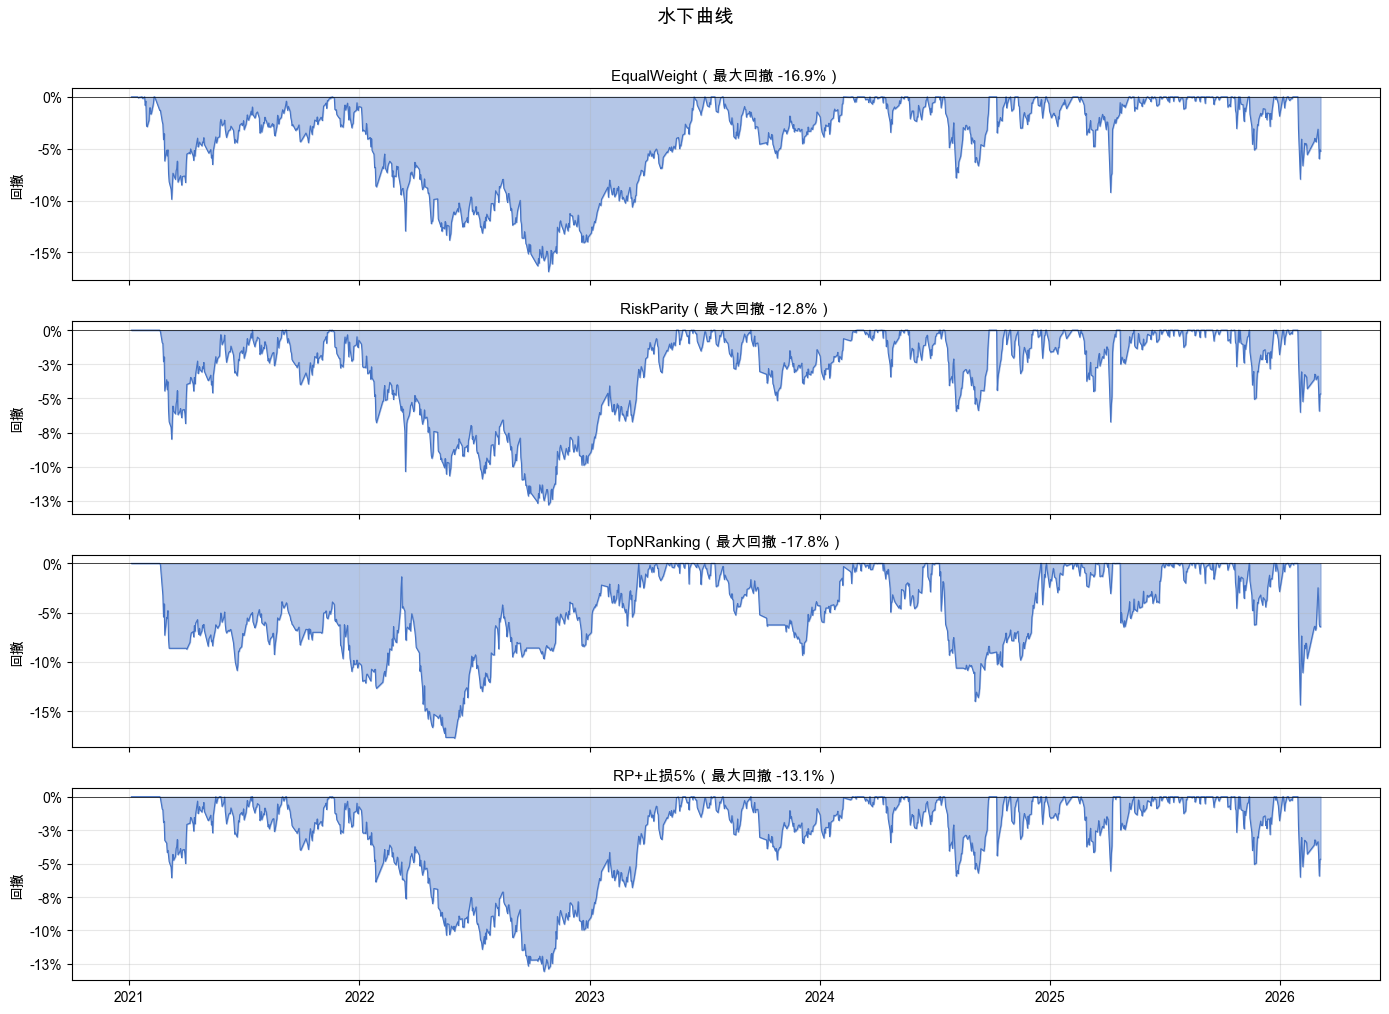


水下曲线告诉你一个残酷的事实：你有多少时间是在'还没回本'的状态中度过的。
回撤不只是一个数字——它是一段煎熬。深度和恢复时间同样重要。

评估够全面了吗？其实还有一个隐藏问题：你用的参数（动量窗口20天、波动率窗口20天）是不是恰好选对了？


In [47]:
# ══════════════════════════════════════════════
# Step 3 续: 回撤深度分析
# ══════════════════════════════════════════════

print("回撤深度分析")
print("=" * 100)

dd_data = {}
for name in strat_names:
    r = results[name]
    dd_series = r.drawdown_series()
    if dd_series.empty:
        continue
    dd_series.index = pd.to_datetime(dd_series.index)

    # 识别回撤事件
    events = []
    start = None
    for date, val in dd_series.items():
        if val < -0.001 and start is None:
            start = date
        elif val >= -0.001 and start is not None:
            dd_slice = dd_series[start:date]
            trough_date = dd_slice.idxmin()
            trough_val = dd_slice.min()
            events.append({
                "start": start, "trough": trough_date, "end": date,
                "depth": trough_val,
                "drawdown_days": (trough_date - start).days,
                "recovery_days": (date - trough_date).days,
                "duration_days": (date - start).days,
            })
            start = None

    # 当前仍在回撤中
    if start is not None:
        dd_slice = dd_series[start:]
        trough_date = dd_slice.idxmin()
        events.append({
            "start": start, "trough": trough_date, "end": None,
            "depth": dd_slice.min(),
            "drawdown_days": (trough_date - start).days,
            "recovery_days": None,
            "duration_days": (dd_series.index[-1] - start).days,
        })

    events.sort(key=lambda e: e["depth"])
    dd_data[name] = {"series": dd_series, "events": events}

    # 打印前 5 大回撤
    top5 = events[:5]
    print(f"\n{name}: 共 {len(events)} 次回撤，前 5 大：")
    print(f"  {'#':<4} {'开始':<12} {'最低点':<12} {'恢复':<12} {'深度':>8} {'下跌天数':>8} {'恢复天数':>8}")
    print(f"  {'-' * 76}")
    for j, e in enumerate(top5):
        end_str = str(e["end"].date()) if e["end"] else "未恢复"
        rec_str = str(e["recovery_days"]) if e["recovery_days"] is not None else "—"
        print(f"  {j+1:<4} {str(e['start'].date()):<12} {str(e['trough'].date()):<12} "
              f"{end_str:<12} {e['depth']:>8.2%} {e['drawdown_days']:>8} {rec_str:>8}")

    # 汇总
    if events:
        depths = [e["depth"] for e in events]
        recovered = [e for e in events if e["recovery_days"] is not None]
        rec_days = [e["recovery_days"] for e in recovered]
        print(f"  最大回撤: {min(depths):.2%}  平均回撤: {np.mean(depths):.2%}", end="")
        if rec_days:
            print(f"  平均恢复: {np.mean(rec_days):.0f}天  最长恢复: {max(rec_days)}天")
        else:
            print()

# ── 水下曲线 ──
fig, axes = plt.subplots(len(strat_names), 1, figsize=(14, 10), sharex=True)

for i, name in enumerate(strat_names):
    ax = axes[i]
    dd = dd_data[name]["series"]
    ax.fill_between(dd.index, dd.values, 0, alpha=0.4, color='#4472C4')
    ax.plot(dd.index, dd.values, color='#4472C4', linewidth=0.8)
    ax.axhline(y=0, color='black', linewidth=0.5)
    max_dd = dd.min()
    ax.set_title(f'{name}（最大回撤 {max_dd:.1%}）', fontsize=11)
    ax.set_ylabel('回撤')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.grid(True, alpha=0.3)

plt.suptitle('水下曲线', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"\n水下曲线告诉你一个残酷的事实：你有多少时间是在'还没回本'的状态中度过的。")
print(f"回撤不只是一个数字——它是一段煎熬。深度和恢复时间同样重要。")
print(f"\n评估够全面了吗？其实还有一个隐藏问题：你用的参数（动量窗口20天、波动率窗口20天）是不是恰好选对了？")

### Step 3 解读

收益结构揭示了"怎么赚的钱"——两个关键维度：

**1. 胜率的陷阱：别追求高胜率**

零基础学员最容易踩的坑：天然觉得"赢的次数越多越好"。但胜率本身意义不大——真正决定收益的是**盈亏比**。

上面的表格显示，四个策略的全时段胜率都差不多（60% 左右）。但我们在 Step 2 看到，TopNRanking 是唯一在 2021 年亏钱的策略。拆解 2021 年的月度数据就能看清原因：

- TopNRanking 2021 年的胜率可能并不低——仍然有超过一半的月份是赚钱的
- 但赚钱的月份平均赚得少，亏钱的月份平均亏得狠——**盈亏比**远低于其他策略
- 结果：虽然赚的月份多，但亏的月份把所有利润全吃掉还倒贴了

对比同年的其他策略——它们不仅胜率相近，而且盈亏比健康：赚的月份赚得多、亏的月份亏得少。**同样的胜率，完全不同的结局。** 这就是为什么胜率是陷阱——它不告诉你"赚多少、亏多少"。

一个更极端的例子：胜率 90%，每次赚 1 元；但亏的那 10% 每次亏 20 元。10 次交易赚 9 元、亏 20 元，净亏 11 元。高胜率，亏钱。

反过来：很多优秀的策略胜率只有 30%-40%，但它们的秘诀是**"小亏大赚"**：
- **小亏**：用止损果断控制每次亏损的幅度，亏了就认，不拖泥带水
- **大赚**：赶上趋势时让利润奔跑，上不封顶

追求高胜率，往往是**捡了芝麻丢了西瓜**——频繁小赚，但一次大亏就全部吐回去。真正决定收益的不是赢的次数，而是赢的时候赚多少。

**盈亏因子**（总盈利 / 总亏损）是最直接的"赚钱效率"指标：大于 1 说明赚的比亏的多，大于 2 算优秀。

**2. 回撤深度：不只是"跌了多少"**

最大回撤只告诉你"最深的坑有多深"，但没告诉你：
- **下跌了多久**——是一天暴跌还是三个月持续下跌？
- **恢复了多久**——跌完多久才爬回来？
- **你在水下待了多久**——水下曲线直观展示这段"煎熬期"

回撤 -15% 但 3 个月恢复，vs 回撤 -10% 但 1 年没恢复——后者对实际持有体验的伤害更大。

**数据说了算：赚钱的方式和赚钱一样重要。** 别被高胜率迷惑，关注盈亏比；别只看回撤深度，还要看恢复时间。

---

## Step 4: 参数动一动，崩不崩？

前面三步的评估都基于特定参数——动量窗口 20 天、波动率窗口 20 天、止损阈值 5%。这些参数是我们"选"的，不是天经地义的。

如果把动量窗口从 20 天改成 15 天或 25 天，结论还成立吗？如果结果剧烈变化，说明你可能只是运气好选对了那个值。

直觉告诉我们：找到最优参数就行了。真的吗？

👉 **打开 `specs/spec-04-parameter-sensitivity.md`，复制到 TRAE。**

In [48]:
# ══════════════════════════════════════════════
# Step 4a: RiskParity 波动率窗口敏感性
# ══════════════════════════════════════════════

vol_periods = [10, 15, 20, 25, 30, 40]
rp_sensitivity = {}

print("RiskParity 波动率窗口敏感性")
print("=" * 70)
print(f"  {'窗口(天)':<10} {'累计收益':>10} {'夏普比':>8} {'卡玛比':>8} {'回撤':>10}")
print(f"  {'-' * 50}")

for p in vol_periods:
    ind = {"vol": (RollingVolatility(), {"column": "close", "period": p})}
    sig = (RiskParity(), {"vol": "vol"})
    r = run_strategy(sig, ind, freq=10)
    rp_sensitivity[p] = r
    print(f"  {p:<10} {r.total_return():>10.2%} {r.sharpe_ratio():>8.2f} "
          f"{r.calmar_ratio():>8.2f} {r.max_drawdown():>10.2%}")

rp_sharpes = [rp_sensitivity[p].sharpe_ratio() for p in vol_periods]
rp_range = max(rp_sharpes) - min(rp_sharpes)
print(f"\n  夏普比范围: {min(rp_sharpes):.2f} ~ {max(rp_sharpes):.2f}  极差: {rp_range:.2f}")

RiskParity 波动率窗口敏感性
  窗口(天)            累计收益      夏普比      卡玛比         回撤
  --------------------------------------------------
  10            104.32%     1.33     1.13    -12.80%
  15            102.65%     1.33     1.13    -12.64%
  20             98.01%     1.29     1.08    -12.81%
  25             96.76%     1.28     1.06    -12.93%
  30            109.29%     1.39     1.10    -13.49%
  40            111.45%     1.40     1.05    -14.37%

  夏普比范围: 1.28 ~ 1.40  极差: 0.13


In [49]:
# ══════════════════════════════════════════════
# Step 4b: TopNRanking 动量窗口敏感性
# ══════════════════════════════════════════════

mom_periods = [10, 15, 20, 25, 30, 40]
tnr_sensitivity = {}

print("TopNRanking 动量窗口敏感性")
print("=" * 70)
print(f"  {'窗口(天)':<10} {'累计收益':>10} {'夏普比':>8} {'卡玛比':>8} {'回撤':>10}")
print(f"  {'-' * 50}")

for p in mom_periods:
    ind = {
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
        "mom": (Momentum(), {"column": "close", "period": p}),
        "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
    }
    sig = (TopNRanking(), {"score": "ram", "n": 3, "filter_negative": True})
    r = run_strategy(sig, ind, freq=10)
    tnr_sensitivity[p] = r
    print(f"  {p:<10} {r.total_return():>10.2%} {r.sharpe_ratio():>8.2f} "
          f"{r.calmar_ratio():>8.2f} {r.max_drawdown():>10.2%}")

tnr_sharpes = [tnr_sensitivity[p].sharpe_ratio() for p in mom_periods]
tnr_range = max(tnr_sharpes) - min(tnr_sharpes)
print(f"\n  夏普比范围: {min(tnr_sharpes):.2f} ~ {max(tnr_sharpes):.2f}  极差: {tnr_range:.2f}")

TopNRanking 动量窗口敏感性
  窗口(天)            累计收益      夏普比      卡玛比         回撤
  --------------------------------------------------
  10            104.21%     1.00     0.72    -19.91%
  15             83.31%     0.85     0.73    -16.78%
  20            153.03%     1.27     1.05    -17.77%
  25            144.73%     1.21     1.10    -16.46%
  30            105.42%     1.02     0.87    -16.64%
  40            101.54%     1.00     0.74    -19.03%

  夏普比范围: 0.85 ~ 1.27  极差: 0.42


止损阈值敏感性（基于 RiskParity 策略，调仓频率 10 天）
  止损阈值               累计收益      夏普比       最大回撤     交易次数
  ----------------------------------------------------
  2%              125.87%     1.63     -9.65%      402
  3%              118.80%     1.56    -11.62%      394
  5%              106.23%     1.43    -13.07%      387
  7%              100.90%     1.36    -13.26%      382
  10%             106.16%     1.40    -12.02%      375
  15%              99.30%     1.32    -12.51%      371
  20%              97.04%     1.29    -13.23%      370
  无止损              98.01%     1.29    -12.81%      369

  夏普比范围: 1.29 ~ 1.63  极差: 0.35

参数敏感性对比
  RiskParity  夏普比极差: 0.13
  TopNRanking 夏普比极差: 0.42
  止损阈值    夏普比极差: 0.35

  RiskParity 是高原型（参数不敏感）
  TopNRanking 是山峰型（参数敏感）


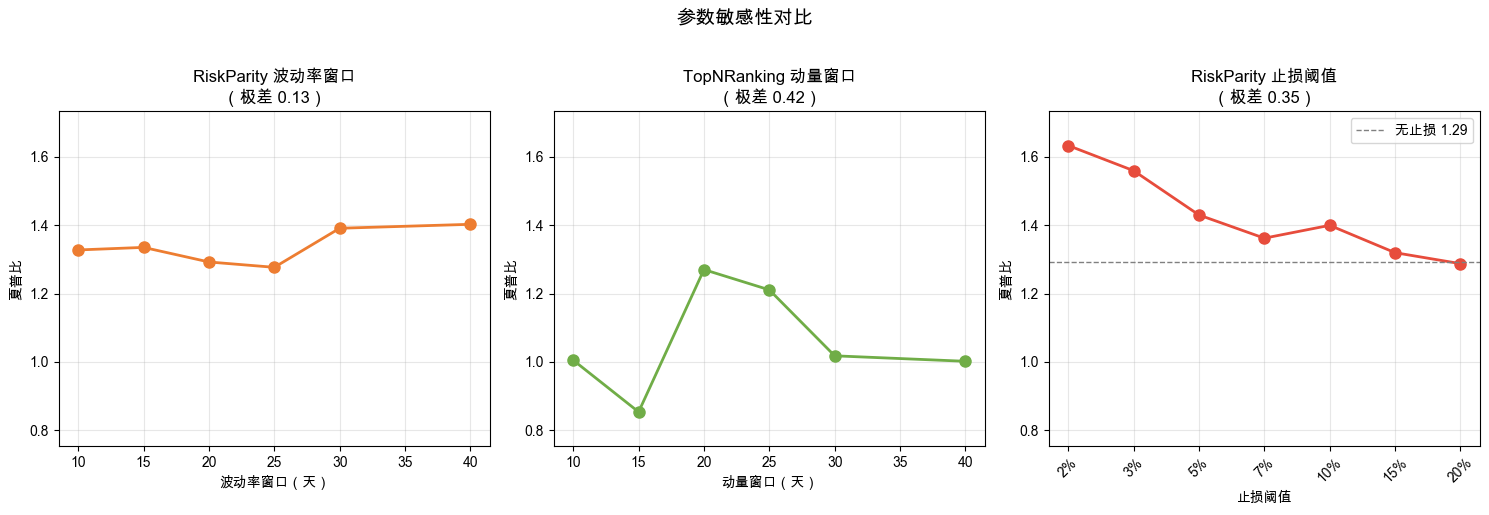


想象你在山上找营地：
  高原型策略像一片平坦的高原——站在哪里都差不多高。参数怎么调，结果变化不大。
  山峰型策略像一座尖峰——只有山尖上最高，稍微偏一步就掉下去。

好策略不依赖某个'魔法参数'。如果换一个参数值结果就崩了，说明你可能只是运气好选对了那个值。
参数敏感性检查是策略评估中不可或缺的一环：plateau >> peak。


In [50]:
# ══════════════════════════════════════════════
# Step 4c: 止损阈值敏感性 + 汇总 + 折线图
# ══════════════════════════════════════════════

sl_thresholds = [0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]
sl_sensitivity = {}

print("止损阈值敏感性（基于 RiskParity 策略，调仓频率 10 天）")
print("=" * 70)
print(f"  {'止损阈值':<12} {'累计收益':>10} {'夏普比':>8} {'最大回撤':>10} {'交易次数':>8}")
print(f"  {'-' * 52}")

for sl in sl_thresholds:
    r = run_strategy(RP_SIG, RP_IND, freq=10, stop_loss=sl)
    sl_sensitivity[sl] = r
    print(f"  {sl:<12.0%} {r.total_return():>10.2%} {r.sharpe_ratio():>8.2f} "
          f"{r.max_drawdown():>10.2%} {len(r.trades):>8}")

# 无止损
r_no_sl = results["RiskParity"]
print(f"  {'无止损':<12} {r_no_sl.total_return():>10.2%} {r_no_sl.sharpe_ratio():>8.2f} "
      f"{r_no_sl.max_drawdown():>10.2%} {len(r_no_sl.trades):>8}")

sl_sharpes = [sl_sensitivity[sl].sharpe_ratio() for sl in sl_thresholds]
sl_range = max(sl_sharpes) - min(sl_sharpes)
print(f"\n  夏普比范围: {min(sl_sharpes):.2f} ~ {max(sl_sharpes):.2f}  极差: {sl_range:.2f}")

# ── 夏普比极差对比 ──
print(f"\n参数敏感性对比")
print("=" * 40)
print(f"  RiskParity  夏普比极差: {rp_range:.2f}")
print(f"  TopNRanking 夏普比极差: {tnr_range:.2f}")
print(f"  止损阈值    夏普比极差: {sl_range:.2f}")

if rp_range < tnr_range:
    print(f"\n  RiskParity 是高原型（参数不敏感）")
    print(f"  TopNRanking 是山峰型（参数敏感）")
else:
    print(f"\n  TopNRanking 是高原型（参数不敏感）")
    print(f"  RiskParity 是山峰型（参数敏感）")

# ── 参数敏感性折线图 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 统一 y 轴范围
all_sharpes = rp_sharpes + tnr_sharpes + sl_sharpes + [r_no_sl.sharpe_ratio()]
y_min = min(all_sharpes) - 0.1
y_max = max(all_sharpes) + 0.1

# 子图 1: RiskParity
ax = axes[0]
ax.plot(vol_periods, rp_sharpes, 'o-', color='#ED7D31', linewidth=2, markersize=8)
ax.set_xlabel('波动率窗口（天）')
ax.set_ylabel('夏普比')
ax.set_title(f'RiskParity 波动率窗口\n（极差 {rp_range:.2f}）')
ax.set_ylim(y_min, y_max)
ax.grid(True, alpha=0.3)

# 子图 2: TopNRanking
ax = axes[1]
ax.plot(mom_periods, tnr_sharpes, 'o-', color='#70AD47', linewidth=2, markersize=8)
ax.set_xlabel('动量窗口（天）')
ax.set_ylabel('夏普比')
ax.set_title(f'TopNRanking 动量窗口\n（极差 {tnr_range:.2f}）')
ax.set_ylim(y_min, y_max)
ax.grid(True, alpha=0.3)

# 子图 3: 止损阈值（基于 RiskParity）
ax = axes[2]
ax.plot([f'{sl:.0%}' for sl in sl_thresholds], sl_sharpes, 'o-', color='#E74C3C', linewidth=2, markersize=8)
ax.axhline(y=r_no_sl.sharpe_ratio(), color='gray', linestyle='--', linewidth=1, label=f'无止损 {r_no_sl.sharpe_ratio():.2f}')
ax.set_xlabel('止损阈值')
ax.set_ylabel('夏普比')
ax.set_title(f'RiskParity 止损阈值\n（极差 {sl_range:.2f}）')
ax.set_ylim(y_min, y_max)
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.suptitle('参数敏感性对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 分析 ──
print(f"\n想象你在山上找营地：")
print(f"  高原型策略像一片平坦的高原——站在哪里都差不多高。参数怎么调，结果变化不大。")
print(f"  山峰型策略像一座尖峰——只有山尖上最高，稍微偏一步就掉下去。")
print(f"\n好策略不依赖某个'魔法参数'。如果换一个参数值结果就崩了，说明你可能只是运气好选对了那个值。")
print(f"参数敏感性检查是策略评估中不可或缺的一环：plateau >> peak。")

### Step 4 解读

最后一个认知升级：**好策略不怕参数变。**

参数敏感性检查揭示了策略的"真面目"：

- **高原型（plateau）**：参数怎么调，结果都差不多。这说明策略的有效性来自底层逻辑，而不是某个特定参数值。RiskParity 就是典型——它的逻辑是"波动大的少买"，不管你用 10 天还是 40 天窗口来衡量波动，排序关系不会剧变。

- **山峰型（peak）**：只有某个特定参数值表现最好，偏了就崩。这说明策略可能在"碰运气"——恰好那个参数值在历史数据上表现好，换个参数或换个时段可能完全不同。

**plateau >> peak。** 选策略就像选营地——你要找的是一片高原，不是一座尖峰。

这也呼应了 Step 2 的发现：TopNRanking 在某些年份负收益、对参数敏感，说明它的高收益可能部分来自"选对了参数"。而 RiskParity 虽然收益不如 TopNRanking 高，但参数稳健、年度一致性好——这才是更可靠的策略。

**数据说了算：参数敏感性是策略体检中不可或缺的一项。不检查参数敏感性，你永远不知道自己是"选对了策略"还是"蒙对了参数"。**

---

## 回头看：你刚才做了什么？

四步实验，一张完整的"策略体检地图"：

```
Step 1: 跟什么比？      → 基准 + Alpha（超额收益）+ 多维指标（夏普比/卡玛比/索提诺比）
Step 2: 每年都有收益吗？ → 分段检验 + 策略类型弱点（动量滞后性）
Step 3: 收益结构什么样？ → 胜率陷阱/盈亏比/盈亏因子 + 回撤深度/恢复时间
Step 4: 参数动一动？    → 参数敏感性 + 高原型 vs 山峰型
```

从今以后，拿到任何策略的回测结果，你都可以用这四步做一次"全面体检"：

| 维度 | 问题 | 好的信号 | 坏的信号 |
|------|------|----------|----------|
| 基准 | 跑赢了吗？ | 稳定的 Alpha | 没跑赢买入持有 |
| 年度 | 每年都赚吗？ | 年度一致性高 | 某些年份大亏 |
| 分布 | 赚法健康吗？ | 小亏大赚 + 盈亏因子 > 1 | 高胜率但盈亏比差 |
| 回撤 | 最坏到什么程度？ | 回撤浅、恢复快 | 回撤深、恢复慢 |
| 参数 | 参数改了还行吗？ | 高原型 | 山峰型 |

**从"看收益率"到"全面体检"——这是本章最重要的认知升级。**

---

## 本章总结

### 四步体检

```
Q4 产出：RiskParity + 止损 + 三个对比策略
    ↓ Step 1: 跟基准比 → 不是所有策略都跑赢了"什么都不做"
    ↓ Step 2: 逐年拆 → 某些年份亏损，动量策略有结构性弱点
    ↓ Step 3: 看分布 → 胜率是陷阱，盈亏比才是关键
    ↓ Step 4: 动参数 → 高原型稳，山峰型脆
    ↓
Q5 产出：完整的策略评估方法论 + "体检清单"
```

### 本章核心认知

| 认知 | 来源 |
|------|------|
| "好不好"必须有参照物——基准 | Step 1 实验 |
| 跑赢基准的部分才是 Alpha——你的技能回报 | Step 1 实验 |
| 夏普比、卡玛比、索提诺比是三把不同的尺子 | Step 1 实验 |
| 整体指标可能掩盖年度亏损——分段检验 | Step 2 实验 |
| 动量策略在反复震荡的市场中有结构性弱点——滞后性 | Step 2 深挖 |
| 胜率是陷阱——真正决定收益的是盈亏比，优秀策略的秘诀是"小亏大赚" | Step 3 实验 |
| 回撤不只是深度，还有恢复时间——水下曲线 | Step 3 实验 |
| 好策略不怕参数变——高原型 >> 山峰型 | Step 4 实验 |
| 先猜后验，数据说了算 | 贯穿全章 |

### 带走的问题

- 体检工具给了你客观数据。但**回测本身可信吗？** 回测能调参数让收益翻倍——这是真的好，还是自欺欺人？ → Q6
- 如果你在 2023 年跑回测发现某个策略 2021-2023 表现好，你怎么知道它 2024 年还会好？ → Q6